# ACF

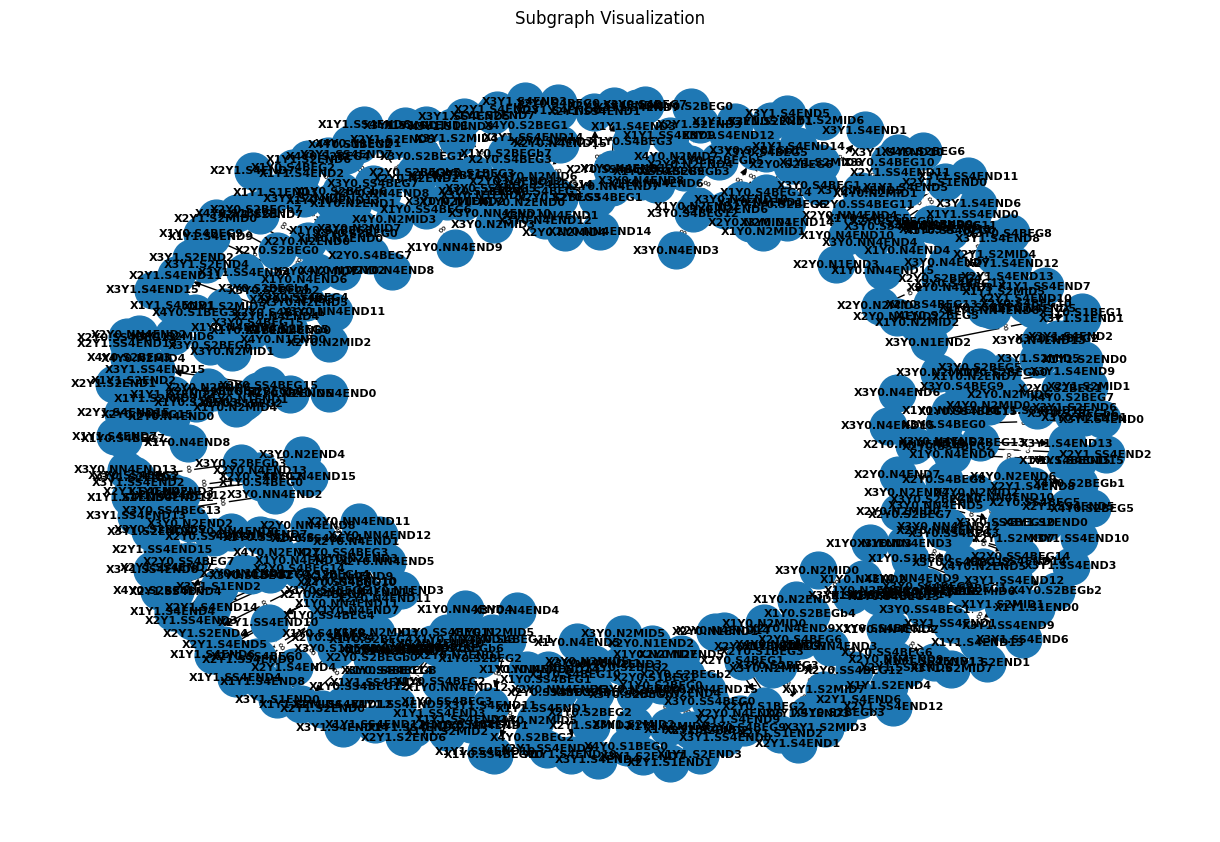

Nodes in the Subgraph:
  X1Y0.S4BEG1
  X1Y0.N4END0
  X1Y0.N2MID6
  X2Y0.S4BEG2
  X1Y0.S1BEG3
  X3Y0.S1BEG3
  X3Y1.S2MID5
  X1Y0.N4END4
  X2Y1.SS4END4
  X3Y0.NN4END1
  X2Y0.S2BEGb3
  X2Y0.N2MID2
  X1Y0.NN4END0
  X3Y0.NN4END7
  X3Y1.S4END3
  X1Y0.S2BEGb0
  X1Y0.S4BEG14
  X3Y1.SS4END8
  X1Y1.S4END7
  X2Y0.S4BEG13
  X1Y0.N2MID3
  X3Y0.NN4END3
  X2Y1.SS4END6
  X2Y1.S4END6
  X1Y0.S4BEG7
  X3Y0.S4BEG0
  X3Y1.S2END5
  X4Y0.S1BEG3
  X2Y1.S4END1
  X4Y0.S2BEG0
  X3Y0.SS4BEG14
  X2Y0.S2BEG4
  X2Y0.SS4BEG11
  X2Y1.S1END3
  X1Y0.N4END3
  X3Y0.SS4BEG9
  X3Y1.S4END0
  X1Y0.NN4END8
  X1Y0.S4BEG10
  X2Y1.S4END13
  X3Y0.NN4END4
  X2Y0.S4BEG8
  X1Y0.NN4END13
  X1Y0.S4BEG9
  X1Y1.SS4END15
  X3Y1.S1END0
  X1Y0.N2END0
  X2Y0.N4END13
  X3Y0.N2END7
  X4Y0.S2BEG5
  X3Y1.SS4END2
  X2Y0.N2END3
  X2Y1.SS4END10
  X2Y0.NN4END9
  X1Y0.SS4BEG15
  X1Y0.S2BEG2
  X1Y0.SS4BEG13
  X2Y0.N4END11
  X3Y0.N1END0
  X2Y1.S4END0
  X4Y0.N2MID0
  X1Y0.S4BEG4
  X3Y1.S2END1
  X3Y0.S4BEG5
  X1Y1.SS4END8
  X1Y1.S4END0
  X1Y0.N2MID1
  X1

In [1]:
from collections import defaultdict, deque
import networkx as nx
import matplotlib.pyplot as plt
from pprint import pprint
import heapq
import re
def parse_bel_file(bel_file):
    # BEL file, extract BEL and pin connections
    bels = []
    with open(bel_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith("#") or not line:
                continue
            parts = line.split(",")
            tile_id, _, _, bel_name, _, *pins = parts
            for pin in pins:
                bel_pin = f"{tile_id}.{pin}"  # Full BEL pin name
                bels.append(bel_pin)  # BEL pin connects to the wire
    return bels

def parse_pips_file(pips_file):
    # Parse the PIPs file to extract connections
    pips = []
    with open(pips_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith("#") or not line:
                continue
            parts = line.split(",")
            if len(parts) < 5:
                continue
            source = f"{parts[0]}.{parts[1]}"
            dest = f"{parts[2]}.{parts[3]}"
            delay = int(parts[4])
            pips.append((source, dest, delay))
    return pips

def build_routing_graph(bels, pips):
    # Build a routing graph from BELs and PIPs
    graph = nx.DiGraph()

    # Add wire-to-wire connections from PIPs
    for source, dest, delay in pips:
        graph.add_edge(source, dest, delay=delay)

    return graph

def visualize_graph(graph, *=500):
    # Visualize a subgraph in the terminal
    # Extract a subgraph if the graph is tooooo large
    subgraph = graph.subgraph(list(graph.nodes)[:limit])

    # Plot the subgraph
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(subgraph)
    nx.draw(subgraph, pos, with_labels=True, node_size=700, font_size=8, font_weight="bold")
    edge_labels = nx.get_edge_attributes(subgraph, "delay")
    nx.draw_networkx_edge_labels(subgraph, pos, edge_labels=edge_labels, font_size=6)
    plt.title("Subgraph Visualization")
    plt.show()

    print("Nodes in the Subgraph:")
    for node in subgraph.nodes:
        print(f"  {node}")

    print("\nEdges in the Subgraph (Source -> Destination | Delay):")
    for source, dest, data in subgraph.edges(data=True):
        print(f"  {source} -> {dest} | Delay: {data['delay']}")

 
bel_file = "bel.txt"
pips_file = "pips.txt"



# Parse the BEL and PIPs files
bels = parse_bel_file(bel_file)
pips = parse_pips_file(pips_file)

# Routing graph
graph = build_routing_graph(bels, pips)

# stdout
visualize_graph(graph)



# BFS Algorithm

In [9]:
def bfs_shortest_path(graph, start, target):
    """
    Find the shortest path from 'start' to 'target' in a directed graph
    (unweighted) using BFS.
    """
    if start == target:
        # Even if start == target, you can print here if needed
        print(f"Queue: 0, Visited: 1, Lookups: 1")
        return [start]

    visited = set([start])  # keep track of visited nodes
    queue = deque([[start]])  # queue holds 'paths' (each element is a list of nodes)

    while queue:
        path = queue.popleft()  # get the oldest path from the queue
        node = path[-1]         # the "current" node is the end of this path

        # If this is the node we're looking for, print debug info & return path
        if node == target:
            print(f"Size of Job queue: {len(queue)}, "
                  f"Size of Visited Nodes: {len(visited)}, "
                  f"Lookups: {len(path)}")
            return path

        # Otherwise, enqueue all unvisited successors
        for neighbor in graph.successors(node):
            if neighbor not in visited:
                visited.add(neighbor)
                new_path = path + [neighbor]
                queue.append(new_path)

    # If BFS completes without finding the target, return None
    return None

# Top left to bottom right
source = "X1Y1.LA_O"
target = "X8Y8.LH_I0"

# Perform BFS
path = bfs_shortest_path(graph, source, target)
if path:
    pprint(f"Path from {source} to {target}: {path}")
else:
    pprint(f"No path found from {source} to {target}.")

print()

# Top left to top right
source = "X1Y1.LA_O"
target = "X8Y1.LH_I0"

# Perform BFS
path = bfs_shortest_path(graph, source, target)
if path:
    pprint(f"Path from {source} to {target}: {path}")
else:
    pprint(f"No path found from {source} to {target}.")

print()

# top left to bottom left
source = "X1Y1.LA_O"
target = "X1Y8.LH_I0"

# Perform BFS
path = bfs_shortest_path(graph, source, target)
if path:
    pprint(f"Path from {source} to {target}: {path}")
else:
    pprint(f"No path found from {source} to {target}.")

print()

#top left to top left
source = "X1Y1.LA_O"
target = "X1Y1.LH_I0"

# Perform BFS
path = bfs_shortest_path(graph, source, target)
if path:
    pprint(f"Path from {source} to {target}: {path}")
else:
    pprint(f"No path found from {source} to {target}.")

Size of Job queue: 663, Size of Visited Nodes: 44875, Lookups: 38
("Path from X1Y1.LA_O to X8Y8.LH_I0: ['X1Y1.LA_O', 'X1Y1.E6BEG0', "
 "'X2Y1.E6END10', 'X2Y1.E6BEG10', 'X3Y1.E6END8', 'X3Y1.E6BEG8', 'X4Y1.E6END6', "
 "'X4Y1.E6BEG6', 'X5Y1.E6END4', 'X5Y1.E6BEG4', 'X6Y1.E6END2', 'X6Y1.E6BEG2', "
 "'X7Y1.E6END0', 'X7Y1.JS2BEG1', 'X7Y1.JS2END1', 'X7Y1.S2BEG1', 'X7Y2.S2MID1', "
 "'X7Y2.S2BEGb1', 'X7Y3.S2END1', 'X7Y3.S4BEG3', 'X7Y4.S4END15', "
 "'X7Y4.S4BEG15', 'X7Y5.S4END11', 'X7Y5.S4BEG11', 'X7Y6.S4END7', "
 "'X7Y6.S4BEG7', 'X7Y7.S4END3', 'X7Y7.J_l_AB_BEG0', 'X7Y7.J_l_AB_END0', "
 "'X7Y7.E1BEG3', 'X8Y7.E1END3', 'X8Y7.JS2BEG6', 'X8Y7.JS2END6', 'X8Y7.S2BEG6', "
 "'X8Y8.S2MID6', 'X8Y8.J2MID_GHa_BEG0', 'X8Y8.J2MID_GHa_END0', 'X8Y8.LH_I0']")

Size of Job queue: 2258, Size of Visited Nodes: 17239, Lookups: 22
("Path from X1Y1.LA_O to X8Y1.LH_I0: ['X1Y1.LA_O', 'X1Y1.EE4BEG1', "
 "'X2Y1.EE4END13', 'X2Y1.EE4BEG13', 'X3Y1.EE4END9', 'X3Y1.EE4BEG9', "
 "'X4Y1.EE4END5', 'X4Y1.EE4BEG5', 'X5Y1.EE4END1', '

###### BFS systematically explores all nodes in “waves” from the source, guaranteeing that the first path it finds to the target is the shortest by edge count.

##### **X1Y1.LA_O → X8Y8.LH_I0**
###### Job Queue Size: 663
###### Visited Nodes: 44,875
###### Path Length (Lookups): 38

##### **X1Y1.LA_O → X8Y1.LH_I0**
###### Job Queue Size: 2,258
###### Visited Nodes: 17,239
###### Path Length (Lookups): 22

##### **X1Y1.LA_O → X1Y8.LH_I0**
###### Job Queue Size: 2,301
###### Visited Nodes: 22,226
###### Path Length (Lookups): 24

##### **X1Y1.LA_O → X1Y1.LH_I0**
###### Job Queue Size: 202
###### Visited Nodes: 551
###### Path Length (Lookups): 6

## Dijkstra's Algorithm

In [14]:
from heapq import heappush, heappop

def dijkstra(graph, source, target):
    """
    Finds the shortest path (minimum 'delay') from 'source' to 'target'
    in a directed graph using Dijkstra's algorithm.
    
    Each edge is assumed to have a 'delay' attribute representing its cost.
    """
    dist = {node: float('inf') for node in graph.nodes()}
    dist[source] = 0

    parent = {node: None for node in graph.nodes()}

    # Min-heap priority queue: (current_cost, current_node)
    pq = []
    heappush(pq, (0, source))

    # Keep track of visited nodes
    visited = set()

    while pq:
        cost_u, node_u = heappop(pq)

        # If already visited, skip
        if node_u in visited:
            continue
        visited.add(node_u)

        # If target is reached, build and return the path along with stats
        if node_u == target:
            # Reconstruct the path from target back to source
            path = []
            cur_node = target
            while cur_node is not None:
                path.append(cur_node)
                cur_node = parent[cur_node]
            path.reverse()

            # Diagnostic print: queue size, visited count, path length, total cost
            print(f"Size of Priority queue: {len(pq)}, "
                  f"Size of Visited Nodes: {len(visited)}, "
                  f"Lookups: {len(path)}, "
                  f"Cost: {cost_u}")

            return path, cost_u
        
        # Relax edges
        for neighbor in graph.successors(node_u):
            edge_cost = graph[node_u][neighbor].get("delay", 1)  # fallback if no delay
            alt_cost = cost_u + edge_cost

            # If this new route is cheaper, update
            if alt_cost < dist[neighbor]:
                dist[neighbor] = alt_cost
                parent[neighbor] = node_u
                heappush(pq, (alt_cost, neighbor))

    # If we exhaust pq without finding target, no path is found
    return None, float('inf')
    
# Top left to bottom right
source = "X1Y1.LA_O"
target = "X8Y8.LH_I0"

# Perform BFS
path = dijkstra(graph, source, target)
if path:
    pprint(f"Path from {source} to {target}: {path}")
else:
    pprint(f"No path found from {source} to {target}.")

print()

# Top left to top right
source = "X1Y1.LA_O"
target = "X8Y1.LH_I0"

# Perform BFS
path = dijkstra(graph, source, target)
if path:
    pprint(f"Path from {source} to {target}: {path}")
else:
    pprint(f"No path found from {source} to {target}.")

print()

# top left to bottom left
source = "X1Y1.LA_O"
target = "X1Y8.LH_I0"

# Perform BFS
path = dijkstra(graph, source, target)
if path:
    pprint(f"Path from {source} to {target}: {path}")
else:
    pprint(f"No path found from {source} to {target}.")

print()

#top left to top left
source = "X1Y1.LA_O"
target = "X1Y1.LH_I0"

# Perform BFS
path = dijkstra(graph, source, target)
if path:
    pprint(f"Path from {source} to {target}: {path}")
else:
    pprint(f"No path found from {source} to {target}.")

Size of Priority queue: 669, Size of Visited Nodes: 44414, Lookups: 38, Cost: 296
("Path from X1Y1.LA_O to X8Y8.LH_I0: (['X1Y1.LA_O', 'X1Y1.E6BEG1', "
 "'X2Y1.E6END11', 'X2Y1.E6BEG11', 'X3Y1.E6END9', 'X3Y1.E6BEG9', 'X4Y1.E6END7', "
 "'X4Y1.E6BEG7', 'X5Y1.E6END5', 'X5Y1.E6BEG5', 'X6Y1.E6END3', 'X6Y1.E6BEG3', "
 "'X7Y1.E6END1', 'X7Y1.S4BEG0', 'X7Y2.S4END12', 'X7Y2.S4BEG12', 'X7Y3.S4END8', "
 "'X7Y3.S4BEG8', 'X7Y4.S4END4', 'X7Y4.S4BEG4', 'X7Y5.S4END0', 'X7Y5.JS2BEG3', "
 "'X7Y5.JS2END3', 'X7Y5.S2BEG3', 'X7Y6.S2MID3', 'X7Y6.S2BEGb3', 'X7Y7.S2END3', "
 "'X7Y7.JE2BEG2', 'X7Y7.JE2END2', 'X7Y7.S1BEG3', 'X7Y8.S1END3', "
 "'X7Y8.JE2BEG6', 'X7Y8.JE2END6', 'X7Y8.E2BEG6', 'X8Y8.E2MID6', "
 "'X8Y8.J2MID_GHa_BEG0', 'X8Y8.J2MID_GHa_END0', 'X8Y8.LH_I0'], 296)")

Size of Priority queue: 1959, Size of Visited Nodes: 17047, Lookups: 22, Cost: 168
("Path from X1Y1.LA_O to X8Y1.LH_I0: (['X1Y1.LA_O', 'X1Y1.E6BEG1', "
 "'X2Y1.E6END11', 'X2Y1.E6BEG11', 'X3Y1.E6END9', 'X3Y1.E6BEG9', 'X4Y1.E6END7', "
 "'X4Y1.E6B

# Dijkstra’s Algorithm for FPGA Routing with Non-Negative Edge Weights

When applying **Dijkstra’s algorithm** to FPGA routing, each directed edge (which may represent a connection through a switch box or a wire segment) must have a **non-negative weight**. In FPGA architectures, the most straightforward choice is typically the **delay** or **time cost** associated with traversing that edge. However, other factors can also influence the cost function, for example:

1. **Propagation Delay (Timing Cost)**
   - The delay through each wire segment or switch can be measured or modeled (e.g., based on parasitic RLC values).
   - Minimizing total path delay helps meet timing constraints in high-speed designs.

2. **Congestion or Utilization Cost**
   - Each edge can be assigned a dynamic penalty if it is heavily used or close to saturation.
   - This spreads routing across multiple paths, preventing overuse of certain tracks and switch boxes.

3. **Power or Energy Cost**
   - Some routes consume more power, either due to longer wire length or repeated switching.
   - Assigning higher weights to power-hungry edges can encourage routing algorithms to find lower-power paths.

4. **Multi-criteria or Combined Cost**
   - A composite function can combine **delay**, **congestion**, **power**, or other factors (e.g., area constraints).
   - For instance, a simple example might be:  
     $$
       \text{cost}(e) = \alpha \times \text{delay}(e) + \beta \times \text{congestion}(e),
     $$  
     where $\alpha$ and $\beta$ control the relative importance of timing vs. congestion.

---

### Example Cost Function

A simple but practical cost function for an FPGA routing edge \( e \) could look like:

$$
\text{cost}(e) = \text{delay}(e) \;+\; \gamma \,\bigl(\text{usage}(e)/\text{capacity}(e)\bigr),
$$

where:
- $\text{delay}(e)$ is the nominal or modeled delay of wire/switch $e$.
- $\text{usage}(e)/\text{capacity}(e)$ is a measure of how congested or overused that resource is.
- $\gamma$ is a tunable parameter that dictates how strongly congestion impacts the cost.

By keeping these edge weights **non-negative**, we can safely apply **Dijkstra’s algorithm** to find the *minimum*-cost path that balances timing, congestion, power, and other objectives in the FPGA fabric.


# A* Algorithm

In [23]:
nodes = graph.nodes
import re

def heuristic(node, tx, ty):
    """
    Heuristic function for A*.
    Extracts X and Y coordinates from the node name and calculates Manhattan distance.
    Args:
        node (str): The current node (e.g., "X2Y1.LA_O").
        tx (int): Target X-coordinate.
        ty (int): Target Y-coordinate.
    Returns:
        int: Manhattan distance to the target coordinates.
    """
    match = re.search(r"X(\d+)Y(\d+)", node)
    if match:
        x, y = map(int, match.groups())
        return abs(tx - x) + abs(ty - y)
    else:
        raise ValueError(f"Invalid node format: {node}")



def a_star_algorithm(graph, source, target):
    """
    A* algorithm to find the shortest path from 'source' to 'target' in a directed graph.
    Assumes each edge has a 'delay' attribute as its cost.
    
    Args:
        graph (nx.DiGraph): The graph to search.
        source (str): Starting node.
        target (str): Target node.
    Returns:
        path (list): The sequence of nodes from source to target (inclusive).
        total_cost (float): The sum of delays along the path.
    """
    # Extract target coordinates
    match = re.search(r"X(\d+)Y(\d+)", target)
    if not match:
        raise ValueError(f"Invalid target format: {target}")
    tx, ty = map(int, match.groups())

    # Initialize distances and parent mapping
    dist = {node: float('inf') for node in graph.nodes()}
    dist[source] = 0
    parent = {node: None for node in graph.nodes()}

    # Priority queue: (f_score, g_cost, node)
    pq = []
    heappush(pq, (0, 0, source))
    visited = set()

    while pq:
        f_score, g_cost, current_node = heappop(pq)

        if current_node in visited:
            continue
        visited.add(current_node)

        # If target is reached, reconstruct and return the path
        if current_node == target:
            path = []
            node = target
            while node is not None:
                path.append(node)
                node = parent[node]
            path.reverse()
            print(f"Size of Priority Queue: {len(pq)}, "
                  f"Size of Visited Nodes: {len(visited)}, "
                  f"Path Length: {len(path)}, "
                  f"Cost: {g_cost}")
            return path, g_cost

        # Explore neighbors
        for neighbor in graph.successors(current_node):
            edge_cost = graph[current_node][neighbor].get("delay", 1)
            tentative_g_cost = g_cost + edge_cost

            if tentative_g_cost < dist[neighbor]:
                dist[neighbor] = tentative_g_cost
                parent[neighbor] = current_node

                # Calculate f_score = g_cost + heuristic
                h_cost = heuristic(neighbor, tx, ty)
                f_score = tentative_g_cost + h_cost

                heappush(pq, (f_score, tentative_g_cost, neighbor))

    # If no path is found
    return None, float('inf')

# Top left to bottom right
source = "X1Y1.LA_O"
target = "X8Y8.LH_I0"

# Perform BFS
path, cost = a_star_algorithm(graph, source, target)
if path:
    pprint(f"Path from {source} to {target}: {path}")
else:
    pprint(f"No path found from {source} to {target}.")

print()

# Top left to top right
source = "X1Y1.LA_O"
target = "X8Y1.LH_I0"

# Perform BFS
path, cost = a_star_algorithm(graph, source, target)
if path:
    pprint(f"Path from {source} to {target}: {path}")
else:
    pprint(f"No path found from {source} to {target}.")

print()

# top left to bottom left
source = "X1Y1.LA_O"
target = "X1Y8.LH_I0"

# Perform BFS
path, cost = a_star_algorithm(graph, source, target)
if path:
    pprint(f"Path from {source} to {target}: {path}")
else:
    pprint(f"No path found from {source} to {target}.")

print()

#top left to top left
source = "X1Y1.LA_O"
target = "X1Y1.LH_I0"

# Perform BFS
path, cost = a_star_algorithm(graph, source, target)
if path:
    pprint(f"Path from {source} to {target}: {path}")
else:
    pprint(f"No path found from {source} to {target}.")

Size of Priority Queue: 699, Size of Visited Nodes: 43946, Path Length: 38, Cost: 296
("Path from X1Y1.LA_O to X8Y8.LH_I0: ['X1Y1.LA_O', 'X1Y1.E6BEG1', "
 "'X2Y1.E6END11', 'X2Y1.E6BEG11', 'X3Y1.E6END9', 'X3Y1.E6BEG9', 'X4Y1.E6END7', "
 "'X4Y1.E6BEG7', 'X5Y1.E6END5', 'X5Y1.E6BEG5', 'X6Y1.E6END3', 'X6Y1.E6BEG3', "
 "'X7Y1.E6END1', 'X7Y1.S4BEG0', 'X7Y2.S4END12', 'X7Y2.S4BEG12', 'X7Y3.S4END8', "
 "'X7Y3.S4BEG8', 'X7Y4.S4END4', 'X7Y4.S4BEG4', 'X7Y5.S4END0', 'X7Y5.JS2BEG3', "
 "'X7Y5.JS2END3', 'X7Y5.S2BEG3', 'X7Y6.S2MID3', 'X7Y6.S2BEGb3', 'X7Y7.S2END3', "
 "'X7Y7.JE2BEG2', 'X7Y7.JE2END2', 'X7Y7.S1BEG3', 'X7Y8.S1END3', "
 "'X7Y8.JE2BEG6', 'X7Y8.JE2END6', 'X7Y8.E2BEG6', 'X8Y8.E2MID6', "
 "'X8Y8.J2MID_GHa_BEG0', 'X8Y8.J2MID_GHa_END0', 'X8Y8.LH_I0']")

Size of Priority Queue: 2042, Size of Visited Nodes: 14399, Path Length: 22, Cost: 168
("Path from X1Y1.LA_O to X8Y1.LH_I0: ['X1Y1.LA_O', 'X1Y1.E6BEG1', "
 "'X2Y1.E6END11', 'X2Y1.E6BEG11', 'X3Y1.E6END9', 'X3Y1.E6BEG9', 'X4Y1.E6END7', "
 "'X4Y1.E6B

("Shortest path from X1Y1.LA_O to X1Y1.LH_I0: ['X1Y1.LA_O', 'X1Y1.JN2BEG4', "
 "'X1Y1.JN2END4', 'X1Y1.J_l_GH_BEG0', 'X1Y1.J_l_GH_END0', 'X1Y1.LH_I0']")
'Cost when target was first reached: 190'


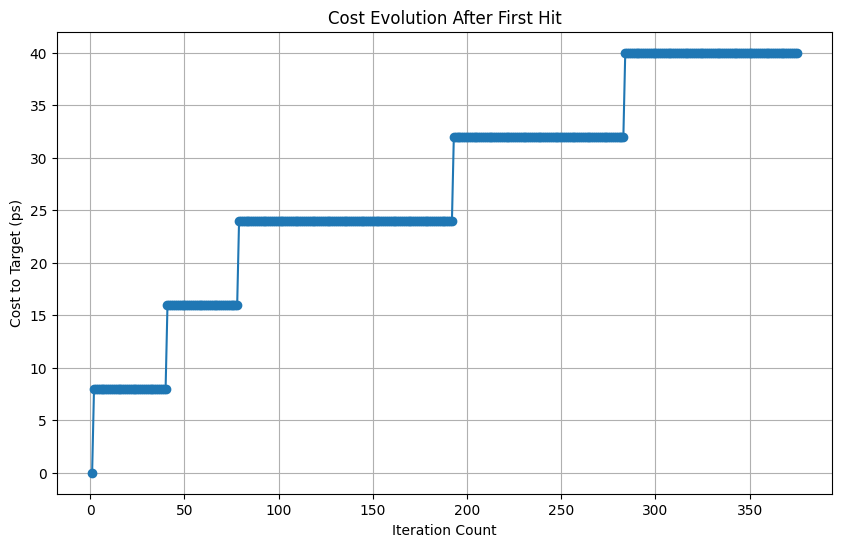

In [27]:
import matplotlib.pyplot as plt
import networkx as nx
from heapq import heappush, heappop
import re

def heuristic(node, tx, ty):
    """
    Heuristic function for A*.
    Calculates Manhattan distance between the current node and the target coordinates.
    """
    match = re.search(r"X(\d+)Y(\d+)", node)
    if match:
        x, y = map(int, match.groups())
        return abs(tx - x) + abs(ty - y)
    else:
        raise ValueError(f"Invalid node format: {node}")

def a_star_with_cost_tracking(graph, source, target, ci=50, ct=20):
    """
    A* algorithm to find the shortest path with cost tracking for reaching the target.
    
    Args:
        graph (nx.DiGraph): The graph to search.
        source (str): Starting node.
        target (str): Target node.
        ci (int): Initial cost for a wire (in ps).
        ct (int): Cost per track type length (in ps).
    Returns:
        path (list): Shortest path from source to target.
        total_cost (float): Total cost of the path.
        cost_history (list): Cost to target over iterations after the first hit.
    """
    # Extract target coordinates
    match = re.search(r"X(\d+)Y(\d+)", target)
    if not match:
        raise ValueError(f"Invalid target format: {target}")
    tx, ty = map(int, match.groups())

    dist = {node: float('inf') for node in graph.nodes()}
    dist[source] = 0
    parent = {node: None for node in graph.nodes()}

    # Priority queue: (f_score, g_cost, node)
    pq = []
    heappush(pq, (0, 0, source))
    visited = set()

    first_hit = False
    cost_history = []  # Store costs to target after the first hit

    while pq:
        f_score, g_cost, current_node = heappop(pq)

        if current_node in visited:
            continue
        visited.add(current_node)

        # If target is reached
        if current_node == target:
            if not first_hit:
                first_hit = True
            cost_history.append(g_cost)

        # Explore neighbors
        for neighbor in graph.successors(current_node):
            # Edge cost = ci + ct * track length
            track_length = graph[current_node][neighbor].get("track_length", 1)
            edge_cost = ci + ct * track_length
            tentative_g_cost = g_cost + edge_cost

            if tentative_g_cost < dist[neighbor]:
                dist[neighbor] = tentative_g_cost
                parent[neighbor] = current_node

                # Calculate f_score = g_cost + heuristic
                h_cost = heuristic(neighbor, tx, ty)
                f_score = tentative_g_cost + h_cost

                heappush(pq, (f_score, tentative_g_cost, neighbor))

    # Reconstruct path
    path = []
    if dist[target] < float('inf'):
        node = target
        while node is not None:
            path.append(node)
            node = parent[node]
        path.reverse()

    return path, dist[target], cost_history

# Define source and target
source = "X1Y1.LA_O"
target = "X1Y1.LH_I0"

# Run the A* algorithm
path, first_cost, cost_history = a_star_with_iteration_tracking(graph, source, target, heuristic)

# Print results
pprint(f"Shortest path from {source} to {target}: {path}")
pprint(f"Cost when target was first reached: {first_cost}")
       
# Plot cost history
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cost_history) + 1), cost_history, marker='o')
plt.title("Cost Evolution After First Hit")
plt.xlabel("Iteration Count")
plt.ylabel("Cost to Target (ps)")
plt.grid(True)
plt.show()



("Shortest path from X1Y1.LA_O to X1Y8.LH_I0: ['X1Y1.LA_O', 'X1Y1.JS2BEG1', "
 "'X1Y1.JS2END1', 'X1Y1.S2BEG1', 'X1Y2.S2MID1', 'X1Y2.S2BEGb1', 'X1Y3.S2END1', "
 "'X1Y3.S4BEG3', 'X1Y4.S4END15', 'X1Y4.S4BEG15', 'X1Y5.S4END11', "
 "'X1Y5.S4BEG11', 'X1Y6.S4END7', 'X1Y6.S4BEG7', 'X1Y7.S4END3', "
 "'X1Y7.J_l_AB_BEG0', 'X1Y7.J_l_AB_END0', 'X1Y7.S1BEG3', 'X1Y8.S1END3', "
 "'X1Y8.JN2BEG6', 'X1Y8.JN2END6', 'X1Y8.J2MID_GHa_BEG0', "
 "'X1Y8.J2MID_GHa_END0', 'X1Y8.LH_I0']")
'Cost when target was first reached: 694'


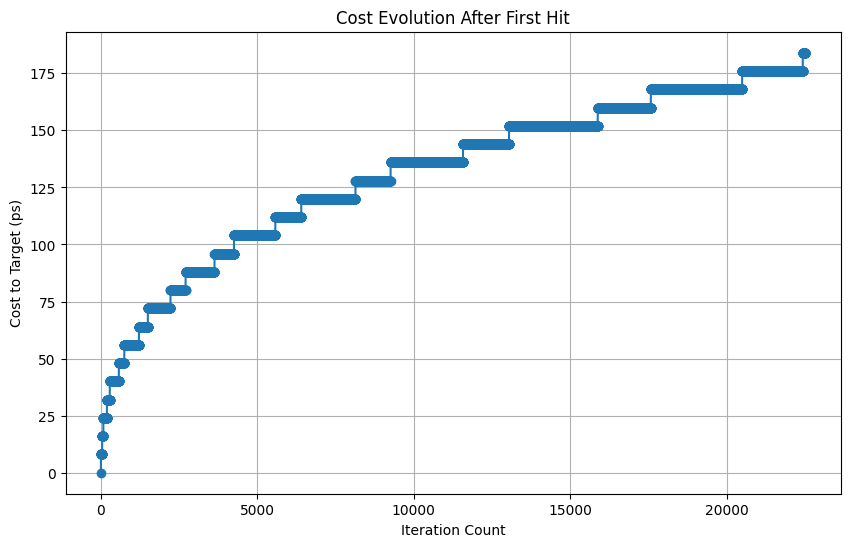

In [28]:
# Define source and target
source = "X1Y1.LA_O"
target = "X1Y8.LH_I0"

# Run the A* algorithm
path, first_cost, cost_history = a_star_with_iteration_tracking(graph, source, target, heuristic)

# Print results
pprint(f"Shortest path from {source} to {target}: {path}")
pprint(f"Cost when target was first reached: {first_cost}")
       
# Plot cost history
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cost_history) + 1), cost_history, marker='o')
plt.title("Cost Evolution After First Hit")
plt.xlabel("Iteration Count")
plt.ylabel("Cost to Target (ps)")
plt.grid(True)
plt.show()


("Shortest path from X1Y1.LA_O to X8Y1.LH_I0: ['X1Y1.LA_O', 'X1Y1.E6BEG1', "
 "'X2Y1.E6END11', 'X2Y1.E6BEG11', 'X3Y1.E6END9', 'X3Y1.E6BEG9', 'X4Y1.E6END7', "
 "'X4Y1.E6BEG7', 'X5Y1.E6END5', 'X5Y1.E6BEG5', 'X6Y1.E6END3', 'X6Y1.E6BEG3', "
 "'X7Y1.E6END1', 'X7Y1.JN2BEG0', 'X7Y1.JN2END0', 'X7Y1.E1BEG1', 'X8Y1.E1END1', "
 "'X8Y1.JN2BEG4', 'X8Y1.JN2END4', 'X8Y1.J_l_GH_BEG0', 'X8Y1.J_l_GH_END0', "
 "'X8Y1.LH_I0']")
'Cost when target was first reached: 638'


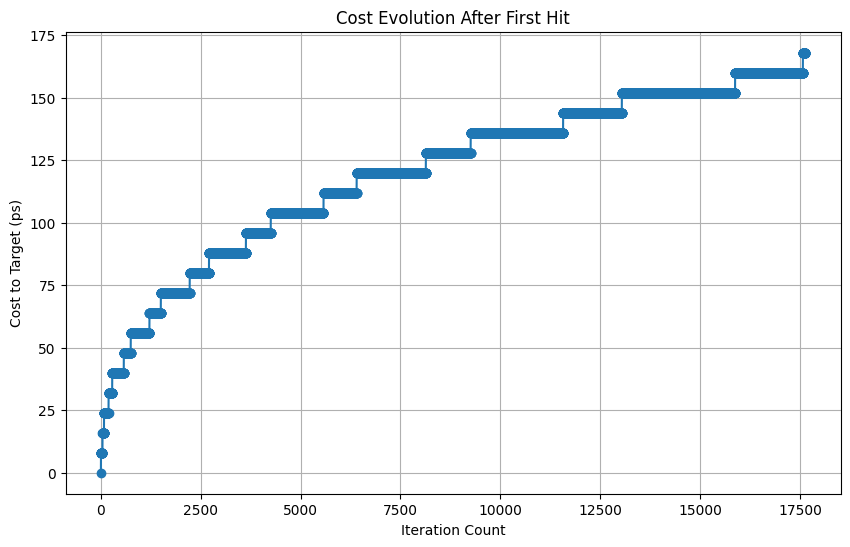

In [29]:
# Define source and target
source = "X1Y1.LA_O"
target = "X8Y1.LH_I0"

# Run the A* algorithm
path, first_cost, cost_history = a_star_with_iteration_tracking(graph, source, target, heuristic)

# Print results
pprint(f"Shortest path from {source} to {target}: {path}")
pprint(f"Cost when target was first reached: {first_cost}")
       
# Plot cost history
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cost_history) + 1), cost_history, marker='o')
plt.title("Cost Evolution After First Hit")
plt.xlabel("Iteration Count")
plt.ylabel("Cost to Target (ps)")
plt.grid(True)
plt.show()


("Shortest path from X1Y1.LA_O to X8Y8.LH_I0: ['X1Y1.LA_O', 'X1Y1.E6BEG0', "
 "'X2Y1.E6END10', 'X2Y1.E6BEG10', 'X3Y1.E6END8', 'X3Y1.E6BEG8', 'X4Y1.E6END6', "
 "'X4Y1.E6BEG6', 'X5Y1.E6END4', 'X5Y1.E6BEG4', 'X6Y1.E6END2', 'X6Y1.E6BEG2', "
 "'X7Y1.E6END0', 'X7Y1.JS2BEG1', 'X7Y1.JS2END1', 'X7Y1.S2BEG1', 'X7Y2.S2MID1', "
 "'X7Y2.J2MID_CDb_BEG3', 'X7Y2.J2MID_CDb_END3', 'X7Y2.E1BEG0', 'X8Y2.E1END0', "
 "'X8Y2.JS2BEG1', 'X8Y2.JS2END1', 'X8Y2.S2BEG1', 'X8Y3.S2MID1', "
 "'X8Y3.S2BEGb1', 'X8Y4.S2END1', 'X8Y4.S4BEG3', 'X8Y5.S4END15', "
 "'X8Y5.S4BEG15', 'X8Y6.S4END11', 'X8Y6.S4BEG11', 'X8Y7.S4END7', "
 "'X8Y7.S4BEG7', 'X8Y8.S4END3', 'X8Y8.J_l_GH_BEG0', 'X8Y8.J_l_GH_END0', "
 "'X8Y8.LH_I0']")
'Cost when target was first reached: 1086'


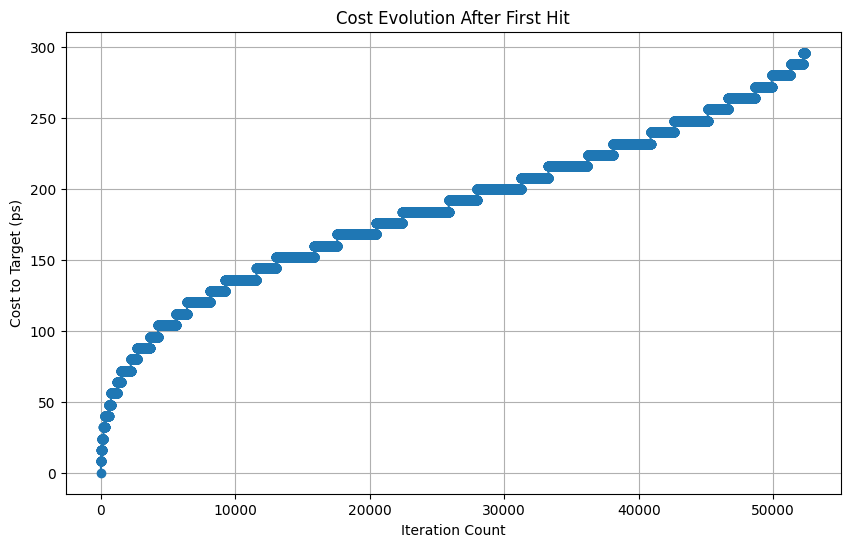

In [30]:
# Define source and target
source = "X1Y1.LA_O"
target = "X8Y8.LH_I0"

# Run the A* algorithm
path, first_cost, cost_history = a_star_with_iteration_tracking(graph, source, target, heuristic)

# Print results
pprint(f"Shortest path from {source} to {target}: {path}")
pprint(f"Cost when target was first reached: {first_cost}")
       
# Plot cost history
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cost_history) + 1), cost_history, marker='o')
plt.title("Cost Evolution After First Hit")
plt.xlabel("Iteration Count")
plt.ylabel("Cost to Target (ps)")
plt.grid(True)
plt.show()
